# RED NEURONAL RECURRENTE PARA PREDECIR EL PRECIO DE LA BOLSA DE VALORES

# 1 - IMPORTAMOS LIBRERIAS

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

# 2 - CARGAMOS DATASET PARA PRECIOS DE COCA COLA COMPANY(KO)

In [2]:
# Descargar datos históricos de KO (Coca-Cola) desde Yahoo Finance
symbol = "KO"
data = yf.download(symbol, start="2025-07-01", end="2026-01-30")

/tmp/ipython-input-1298707816.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2025-07-01", end="2026-01-30")
[*********************100%***********************]  1 of 1 completed


In [3]:
data

Price,Close,High,Low,Open,Volume
Ticker,KO,KO,KO,KO,KO
Date,,,,,
2025-07-01,70.628456,71.397120,69.869649,69.958338,21729300
2025-07-02,69.879501,70.786130,69.711966,70.648165,13050200
2025-07-03,70.313103,70.362379,69.426180,70.007610,9440500
2025-07-07,69.978050,70.332819,69.771103,70.332819,16984700
2025-07-08,69.219231,69.652839,68.864462,69.652839,17115500
...,...,...,...,...,...
2026-01-23,72.879997,73.059998,71.779999,72.019997,18307100
2026-01-26,72.559998,73.300003,72.540001,72.860001,14017400


In [4]:
data.columns

MultiIndex([( 'Close', 'KO'),
            (  'High', 'KO'),
            (   'Low', 'KO'),
            (  'Open', 'KO'),
            ('Volume', 'KO')],
           names=['Price', 'Ticker'])

## 3 - RENOMBRAMOS LAS COLUMNAS

In [5]:
# Renombrar las columnas eliminando el MultiIndex y aplicando snake_case
data.columns = [f"{col[0].lower()}_{col[1].lower()}" for col in data.columns]

# Mostrar las nuevas columnas
print(data.head())

             close_ko    high_ko     low_ko    open_ko  volume_ko
Date                                                             
2025-07-01  70.628456  71.397120  69.869649  69.958338   21729300
2025-07-02  69.879501  70.786130  69.711966  70.648165   13050200
2025-07-03  70.313103  70.362379  69.426180  70.007610    9440500
2025-07-07  69.978050  70.332819  69.771103  70.332819   16984700
2025-07-08  69.219231  69.652839  68.864462  69.652839   17115500


## 4 - MODIFICAMOS EL DATASET PARA TRABAJAR SOLO CON EL CLOSE_KO

In [6]:
df = data[['close_ko']]
df = df.rename(columns={'close_ko': 'close'})

In [7]:
df

,close
Date,
2025-07-01,70.628456
2025-07-02,69.879501
2025-07-03,70.313103
2025-07-07,69.978050
2025-07-08,69.219231
...,...
2026-01-23,72.879997
2026-01-26,72.559998
2026-01-27,73.550003


## ESCALAMOS LOS DATOS

In [8]:
# Normalización de datos
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)
df_scaled

array([[0.6496124 ],
       [0.5597886 ],
       [0.61179137],
       [0.57160778],
       [0.48060087],
       [0.39077798],
       [0.42505152],
       [0.43687162],
       [0.38959579],
       [0.37659441],
       [0.36595741],
       [0.52196756],
       [0.43450723],
       [0.46050908],
       [0.41205197],
       [0.35295786],
       [0.3458647 ],
       [0.35413914],
       [0.2264943 ],
       [0.37895788],
       [0.30449984],
       [0.20285593],
       [0.3175003 ],
       [0.32931857],
       [0.33995648],
       [0.39432273],
       [0.50305796],
       [0.49241914],
       [0.54087717],
       [0.53615022],
       [0.50660271],
       [0.3990515 ],
       [0.44277984],
       [0.34941128],
       [0.4676004 ],
       [0.53496803],
       [0.53024109],
       [0.4676004 ],
       [0.32577382],
       [0.30213637],
       [0.31395464],
       [0.2584062 ],
       [0.33286424],
       [0.34113776],
       [0.33286424],
       [0.24540482],
       [0.21113037],
       [0.148

## 5 - CREAMOS SERIES TEMPORALES(SECUENCIAS)

In [9]:
def create_sequences(data, seq_length):
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

In [11]:
# Definir la longitud de la secuencia (días pasados usados para predecir)
SEQ_LENGTH = 7  # 7 días de datos para predecir el siguiente
X, y = create_sequences(df_scaled, SEQ_LENGTH)

## 6 -  DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [12]:
from sklearn.model_selection import train_test_split

# Dividir en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 7 - CREAMOS RED NEURONAL RECURRENTE

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    tf.keras.layers.LSTM(50, return_sequences=False),
    tf.keras.layers.Dense(25, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_data=(X_test, y_test))

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.2364 - val_loss: 0.2318
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.2199 - val_loss: 0.2148
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.2041 - val_loss: 0.1970
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.1874 - val_loss: 0.1785
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.1702 - val_loss: 0.1597
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.1528 - val_loss: 0.1408
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.1353 - val_loss: 0.1218
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.1178 - val_loss: 0.1028
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.1002 - val_loss: 0.0841
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0831 - val_loss: 0.0660
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0667 - val_loss: 0.0493
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0516 - val_los

# 8 - CREAMOS GRAFICO DE PREDICCIONES

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


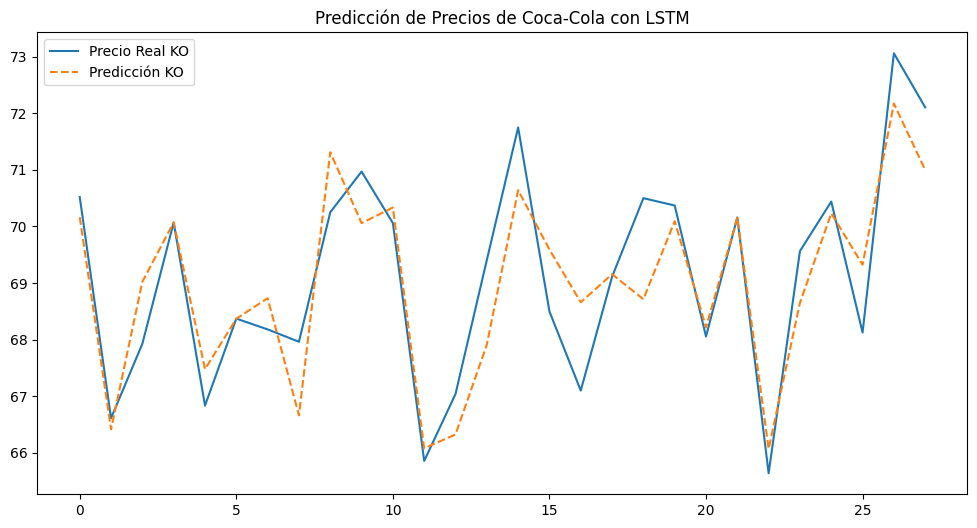

In [15]:
# Predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Invertir la escala de los valores reales
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Visualizar los resultados
plt.figure(figsize=(12,6))
plt.plot(real_prices, label="Precio Real KO")
plt.plot(predictions, label="Predicción KO", linestyle="dashed")
plt.legend()
plt.title("Predicción de Precios de Coca-Cola con LSTM")
plt.show()

## 9 - REALIZAMOS PREDICCIÓN PARA LOS SIGUIENTES 30 DIAS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━

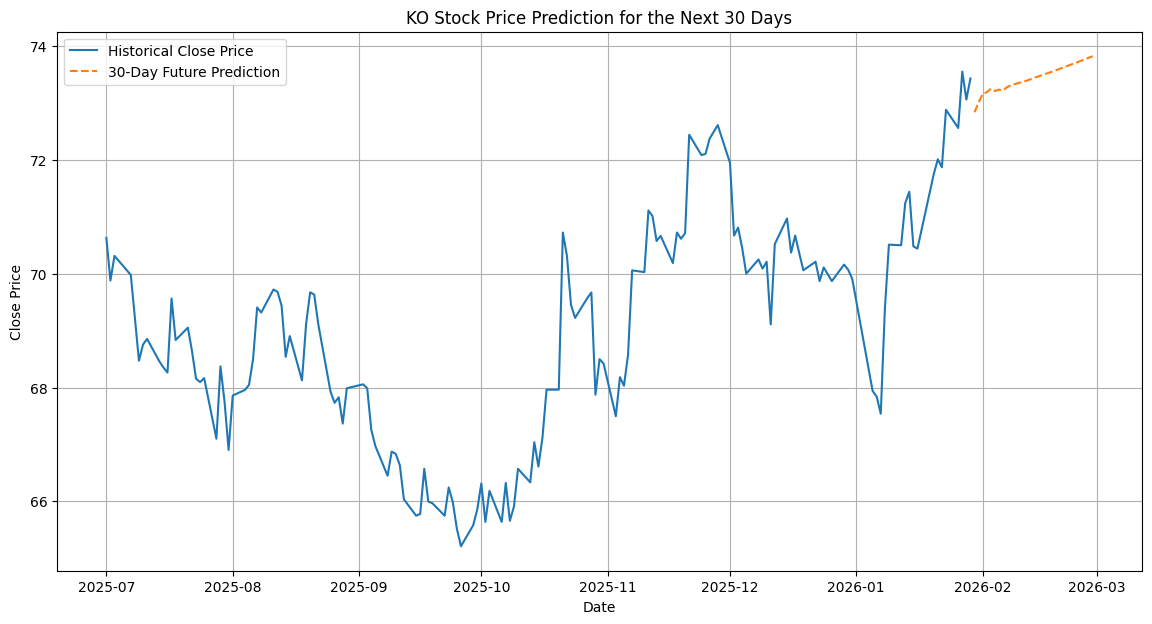

In [16]:
# Prepare initial sequence for future predictions
last_sequence = df_scaled[-SEQ_LENGTH:]
future_predictions = []

# Predict future prices
current_sequence = last_sequence.reshape(1, SEQ_LENGTH, 1)

for _ in range(30): # Predict for the next 30 days
    next_day_prediction = model.predict(current_sequence)[0]
    future_predictions.append(next_day_prediction)
    # Update the sequence: remove the first element and add the new prediction
    current_sequence = np.append(current_sequence[:, 1:, :], [[next_day_prediction]], axis=1)

# Inverse transform predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Generate future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=31, freq='D')[1:] # Start from the day after the last available data

# Create a DataFrame for historical data
historical_data = df.copy()

# Create a DataFrame for future predictions
future_df = pd.DataFrame(future_predictions, index=future_dates, columns=['Predicted Close'])

# Visualize predictions
plt.figure(figsize=(14, 7))
plt.plot(historical_data.index, historical_data['close'], label='Historical Close Price')
plt.plot(future_df.index, future_df['Predicted Close'], label='30-Day Future Prediction', linestyle='--')
plt.title(f'KO Stock Price Prediction for the Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()